U24AI063  
SUNIL JAAT
                    Lab-Assignment-01

# Experiment 1: Frequency Analysis and Probability in Data Science Using Python

**Aim:** To perform frequency analysis, calculate probability measures, and analyze correlation using the Titanic dataset in Python.

**Objectives**
- Create frequency tables for categorical variables.
- Compute absolute, relative, and cumulative frequencies.
- Calculate joint, marginal, and conditional probabilities.
- Construct contingency tables using Pandas.
- Analyze the correlation between numerical variables.
- Visualize relationships using heatmaps, scatter plots, and bar charts.

## Step 0: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Step 1: Load the Titanic Dataset

In [2]:
# Option A (preferred, uses seaborn's built-in loader):
df = sns.load_dataset("titanic")

# Option B: if Option A fails (e.g. network/proxy issue), uncomment this instead:
# df = pd.read_csv(
#     "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
# )

print("Dataset loaded successfully!")
print("Shape of dataset (rows, columns):", df.shape)
df.head()

Dataset loaded successfully!
Shape of dataset (rows, columns): (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Part I: Frequency Analysis

We build a frequency table for the passenger `class` column, showing absolute frequency (raw counts), relative frequency (%), and cumulative frequency (running total).

In [4]:
# Absolute Frequency
absolute_freq = df["class"].value_counts()
print("Absolute Frequency (raw counts):")
print(absolute_freq)

Absolute Frequency (raw counts):
class
Third     491
First     216
Second    184
Name: count, dtype: int64


In [5]:
# Relative Frequency (%)
relative_freq = (df["class"].value_counts(normalize=True) * 100).round(2)
print("Relative Frequency (%):")
print(relative_freq)

Relative Frequency (%):
class
Third     55.11
First     24.24
Second    20.65
Name: proportion, dtype: float64


In [6]:
# Cumulative Frequency
cumulative_freq = absolute_freq.cumsum()
print("Cumulative Frequency:")
print(cumulative_freq)

Cumulative Frequency:
class
Third     491
First     707
Second    891
Name: count, dtype: int64


In [7]:
# Combine into one complete frequency table
freq_table = pd.DataFrame({
    "Absolute Frequency": absolute_freq,
    "Relative Frequency (%)": relative_freq,
    "Cumulative Frequency": cumulative_freq
})
freq_table

,Absolute Frequency,Relative Frequency (%),Cumulative Frequency
class,,,
Third,491,55.11,491
First,216,24.24,707
Second,184,20.65,891


## Part II: Probability Analysis (Sex vs Survived)

Using a contingency table built with `pd.crosstab()`, we compute:
- **Joint probability** P(Sex AND Survived) — normalize over the grand total
- **Marginal probability** P(Sex) or P(Survived) — normalize a single variable
- **Conditional probability** P(Survived | Sex) — normalize within each row

In [8]:
# Contingency Table (counts), with row/column totals
contingency_counts = pd.crosstab(df["sex"], df["survived"], margins=True, margins_name="Total")
contingency_counts

survived,0,1,Total
sex,,,
female,81,233,314
male,468,109,577
Total,549,342,891


In [9]:
# Joint Probability: P(Sex AND Survived)
joint_prob = pd.crosstab(df["sex"], df["survived"], normalize="all").round(4)
joint_prob

survived,0,1
sex,,
female,0.0909,0.2615
male,0.5253,0.1223


In [10]:
# Marginal Probability of Sex: P(Sex)
marginal_prob_sex = df["sex"].value_counts(normalize=True).round(4)
print("P(Sex):")
print(marginal_prob_sex)

P(Sex):
sex
male      0.6476
female    0.3524
Name: proportion, dtype: float64


In [11]:
# Marginal Probability of Survived: P(Survived)
marginal_prob_survived = df["survived"].value_counts(normalize=True).round(4)
print("P(Survived):")
print(marginal_prob_survived)

P(Survived):
survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64


In [12]:
# Conditional Probability: P(Survived | Sex)
conditional_prob_survived_given_sex = pd.crosstab(
    df["sex"], df["survived"], normalize="index"
).round(4)
conditional_prob_survived_given_sex

survived,0,1
sex,,
female,0.2580,0.7420
male,0.8111,0.1889


In [13]:
# Conditional Probability: P(Sex | Survived)
conditional_prob_sex_given_survived = pd.crosstab(
    df["sex"], df["survived"], normalize="columns"
).round(4)
conditional_prob_sex_given_survived

survived,0,1
sex,,
female,0.1475,0.6813
male,0.8525,0.3187


## Part III: Correlation Analysis (Age vs Fare)

We select `age` and `fare`, handle missing values, compute the Pearson correlation, and visualize it.

In [14]:
age_fare = df[["age", "fare"]].copy()
print("Missing values before handling:")
print(age_fare.isnull().sum())

Missing values before handling:
age     177
fare      0
dtype: int64


In [24]:
# Fill missing Age with the median (robust to outliers/skew)
age_fare["age"] = age_fare["age"].fillna(age_fare["age"].mean())

print("Missing values after handling:")
print(age_fare.isnull().sum())

Missing values after handling:
age     0
fare    0
dtype: int64


In [25]:
age_fare

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,28.0,23.4500
889,26.0,30.0000


In [ ]:
pearson_corr = age_fare["age"].corr(age_fare["fare"], method="pearson")
print(f"Pearson correlation coefficient between Age and Fare: {pearson_corr:.4f}")

corr_matrix = age_fare.corr(method="pearson")
corr_matrix

Pearson correlation coefficient between Age and Fare: 0.0967


,age,fare
age,1.000000,0.096688
fare,0.096688,1.000000


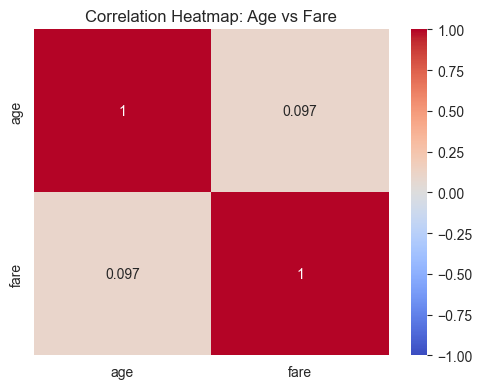

In [17]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Age vs Fare")
plt.tight_layout()
plt.show()

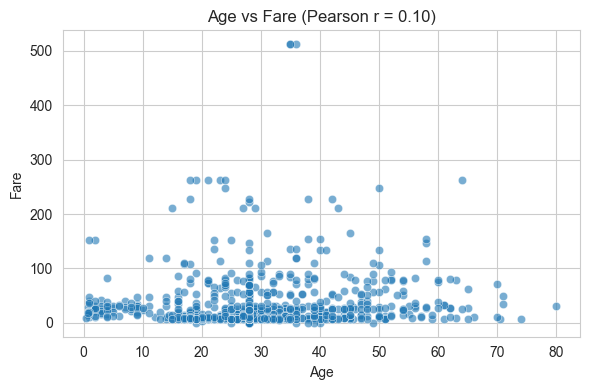

In [18]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=age_fare, x="age", y="fare", alpha=0.6)
plt.title(f"Age vs Fare (Pearson r = {pearson_corr:.2f})")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

### Bonus: Stacked Bar Chart — Survival by Passenger Class

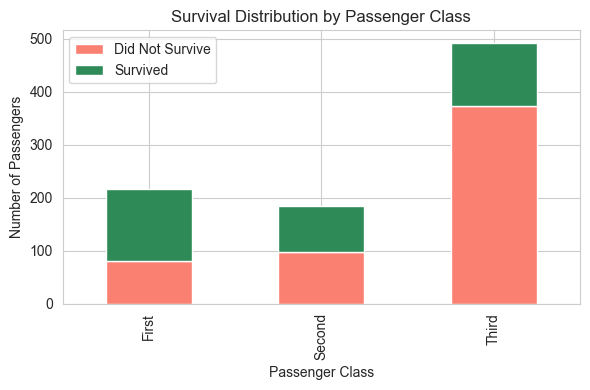

In [27]:
survival_by_class = pd.crosstab(df["class"], df["survived"])
survival_by_class.plot(kind="bar", stacked=True, figsize=(6, 4), color=["salmon", "seagreen"])
plt.title("Survival Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])
plt.tight_layout()
plt.show()

## Exercises / Assignments

1. Frequency table for the `Embarked` variable
2. Probability that a passenger survived
3. Pearson correlation between Age and Fare
4. Stacked bar chart showing survival by passenger class
5. Interpretation of the correlation coefficient

In [20]:
# 1. Frequency table for 'embarked'
embarked_abs = df["embarked"].value_counts()
embarked_rel = (df["embarked"].value_counts(normalize=True) * 100).round(2)
embarked_cum = embarked_abs.cumsum()
embarked_table = pd.DataFrame({
    "Absolute Frequency": embarked_abs,
    "Relative Frequency (%)": embarked_rel,
    "Cumulative Frequency": embarked_cum
})
embarked_table

,Absolute Frequency,Relative Frequency (%),Cumulative Frequency
embarked,,,
S,644,72.44,644
C,168,18.90,812
Q,77,8.66,889


In [21]:
# 2. Probability that a passenger survived
p_survived = df["survived"].mean()
print(f"P(Survived) = {p_survived:.4f} ({p_survived*100:.2f}%)")

P(Survived) = 0.3838 (38.38%)


In [22]:
# 3. Pearson correlation between Age and Fare (already computed above)
print(f"Pearson correlation (Age, Fare) = {pearson_corr:.4f}")

Pearson correlation (Age, Fare) = 0.0967


4. Stacked bar chart — already generated above in Part III.

In [23]:
# 5. Interpretation of the correlation coefficient
if abs(pearson_corr) < 0.1:
    strength = "negligible"
elif abs(pearson_corr) < 0.3:
    strength = "weak"
elif abs(pearson_corr) < 0.5:
    strength = "moderate"
else:
    strength = "strong"
direction = "positive" if pearson_corr > 0 else "negative"

print(f"The correlation of {pearson_corr:.2f} indicates a {strength} {direction} "
      f"linear relationship between Age and Fare — a passenger's age gives very "
      f"little information about how much they paid for their ticket.")

The correlation of 0.10 indicates a negligible positive linear relationship between Age and Fare — a passenger's age gives very little information about how much they paid for their ticket.


## Conclusion

Frequency analysis, probability calculations, and correlation analysis were successfully performed using the Titanic dataset. Contingency tables helped compute joint, marginal, and conditional probabilities, while Pearson correlation measured the relationship between Age and Fare. Data visualization techniques such as heatmaps, scatter plots, and stacked bar charts made the analysis more meaningful and easier to interpret.